# Exploración de Datos — 7 Empresas BVL (universo vigente)

Visualización del pipeline de mercado (R3): datos de BVL/Yahoo Finance, capa de
ajuste por acciones corporativas (splits y dividendos, fuente BVL) e indicadores
técnicos.

Horizonte efectivo: **2012–2025** (la BVL es la fuente primaria y determina el
horizonte; Yahoo solo enriquece OHLCV puntual y no extiende la cobertura hacia
atrás — ver `docs/pipeline_extraccion_datos.txt`, sección 2). Panel con la
**corrección de fecha del 2026-09-12** (el endpoint de la BVL rotulaba cada cierre
con el día hábil siguiente; ver `docs/hallazgos_desfase_fecha_bvl.txt`).

| Ticker | Empresa | Sector |
|--------|---------|--------|
| CREDITC1 | Banco de Crédito del Perú | Banca |
| ALICORC1 | Alicorp | Alimentos |
| INRETC1 | InRetail Peru Corp (cotiza en US$, convertido a S/) | Retail / farmacias |
| CPACASC1 | Cementos Pacasmayo | Construcción |
| FERREYC1 | Ferreycorp | Bienes de capital |
| LUSURC1 | Luz del Sur | Electricidad |
| MINSURI1 | Minsur (acción de inversión) | Minería (estaño/cobre) |

InRetail sale a bolsa el 2012-10-05: su serie empieza ahí.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_RAW     = pathlib.Path('../data/raw')
DATA_INTERIM = pathlib.Path('../data/interim')

TICKERS = ['CREDITC1', 'ALICORC1', 'INRETC1', 'CPACASC1', 'FERREYC1', 'LUSURC1', 'MINSURI1']
NOMBRES = {
    'CREDITC1': 'BCP',
    'ALICORC1': 'Alicorp',
    'INRETC1':  'InRetail',
    'CPACASC1': 'Pacasmayo',
    'FERREYC1': 'Ferreycorp',
    'LUSURC1':  'Luz del Sur',
    'MINSURI1': 'Minsur',
}
# Paleta categórica de 7 colores distinguibles (tab10 sin rojo/verde contiguos)
COLORES = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
COLOR_MAP = dict(zip(TICKERS, COLORES))

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12})

## 1. Carga de datos

In [2]:
# Datos crudos (BVL y Yahoo por separado)
raw = {}
for ticker in TICKERS:
    partes = {}
    for src in ('bvl', 'yahoo'):
        p = DATA_RAW / f'market_{ticker}_{src}.parquet'
        if p.exists():
            partes[src] = pd.read_parquet(p)
    raw[ticker] = partes

# Datos interim (fusionados + indicadores técnicos)
interim = {}
for ticker in TICKERS:
    p = DATA_INTERIM / f'market_{ticker}.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date')
        interim[ticker] = df

print(f'Empresas con datos interim: {list(interim.keys())}')

Empresas con datos interim: ['CREDITC1', 'ALICORC1', 'INRETC1', 'CPACASC1', 'FERREYC1', 'LUSURC1', 'MINSURI1']


## 2. Resumen estadístico

In [3]:
resumen = []
for ticker, df in interim.items():
    resumen.append({
        'Ticker':       ticker,
        'Empresa':      NOMBRES[ticker],
        'Registros':    len(df),
        'Fecha inicio': df['date'].min().strftime('%Y-%m-%d'),
        'Fecha fin':    df['date'].max().strftime('%Y-%m-%d'),
        'Años de datos': round((df['date'].max() - df['date'].min()).days / 365, 1),
        'Precio min (S/)': round(df['close_raw'].min(), 2),
        'Precio max (S/)': round(df['close_raw'].max(), 2),
        'Precio actual (S/)': round(df['close_raw'].iloc[-1], 2),
        'Volumen prom.': df['volume'].mean(),
        'NaN en close': int(df['close'].isna().sum()),
    })

df_resumen = pd.DataFrame(resumen).set_index('Ticker')
df_resumen

,Empresa,Registros,Fecha inicio,Fecha fin,Años de datos,Precio min (S/),Precio max (S/),Precio actual (S/),Volumen prom.,NaN en close
Ticker,,,,,,,,,,
CREDITC1,BCP,3510,2012-01-02,2025-12-30,14.0,1.98,8.40,5.60,543958.130575,0
ALICORC1,Alicorp,3512,2012-01-02,2025-12-30,14.0,3.90,11.99,10.70,373148.038428,0
INRETC1,InRetail,3320,2012-10-05,2025-12-30,13.2,37.63,167.05,84.22,NaN,0
CPACASC1,Pacasmayo,3512,2012-01-02,2025-12-30,14.0,3.52,8.59,7.00,NaN,0
FERREYC1,Ferreycorp,3512,2012-01-02,2025-12-30,14.0,1.05,3.84,3.84,NaN,0
LUSURC1,Luz del Sur,3512,2012-01-02,2025-12-30,14.0,6.54,29.25,12.10,NaN,0
MINSURI1,Minsur,3512,2012-01-02,2025-12-30,14.0,0.45,6.28,5.43,NaN,0


## 3. Fuentes de datos: BVL vs Yahoo Finance

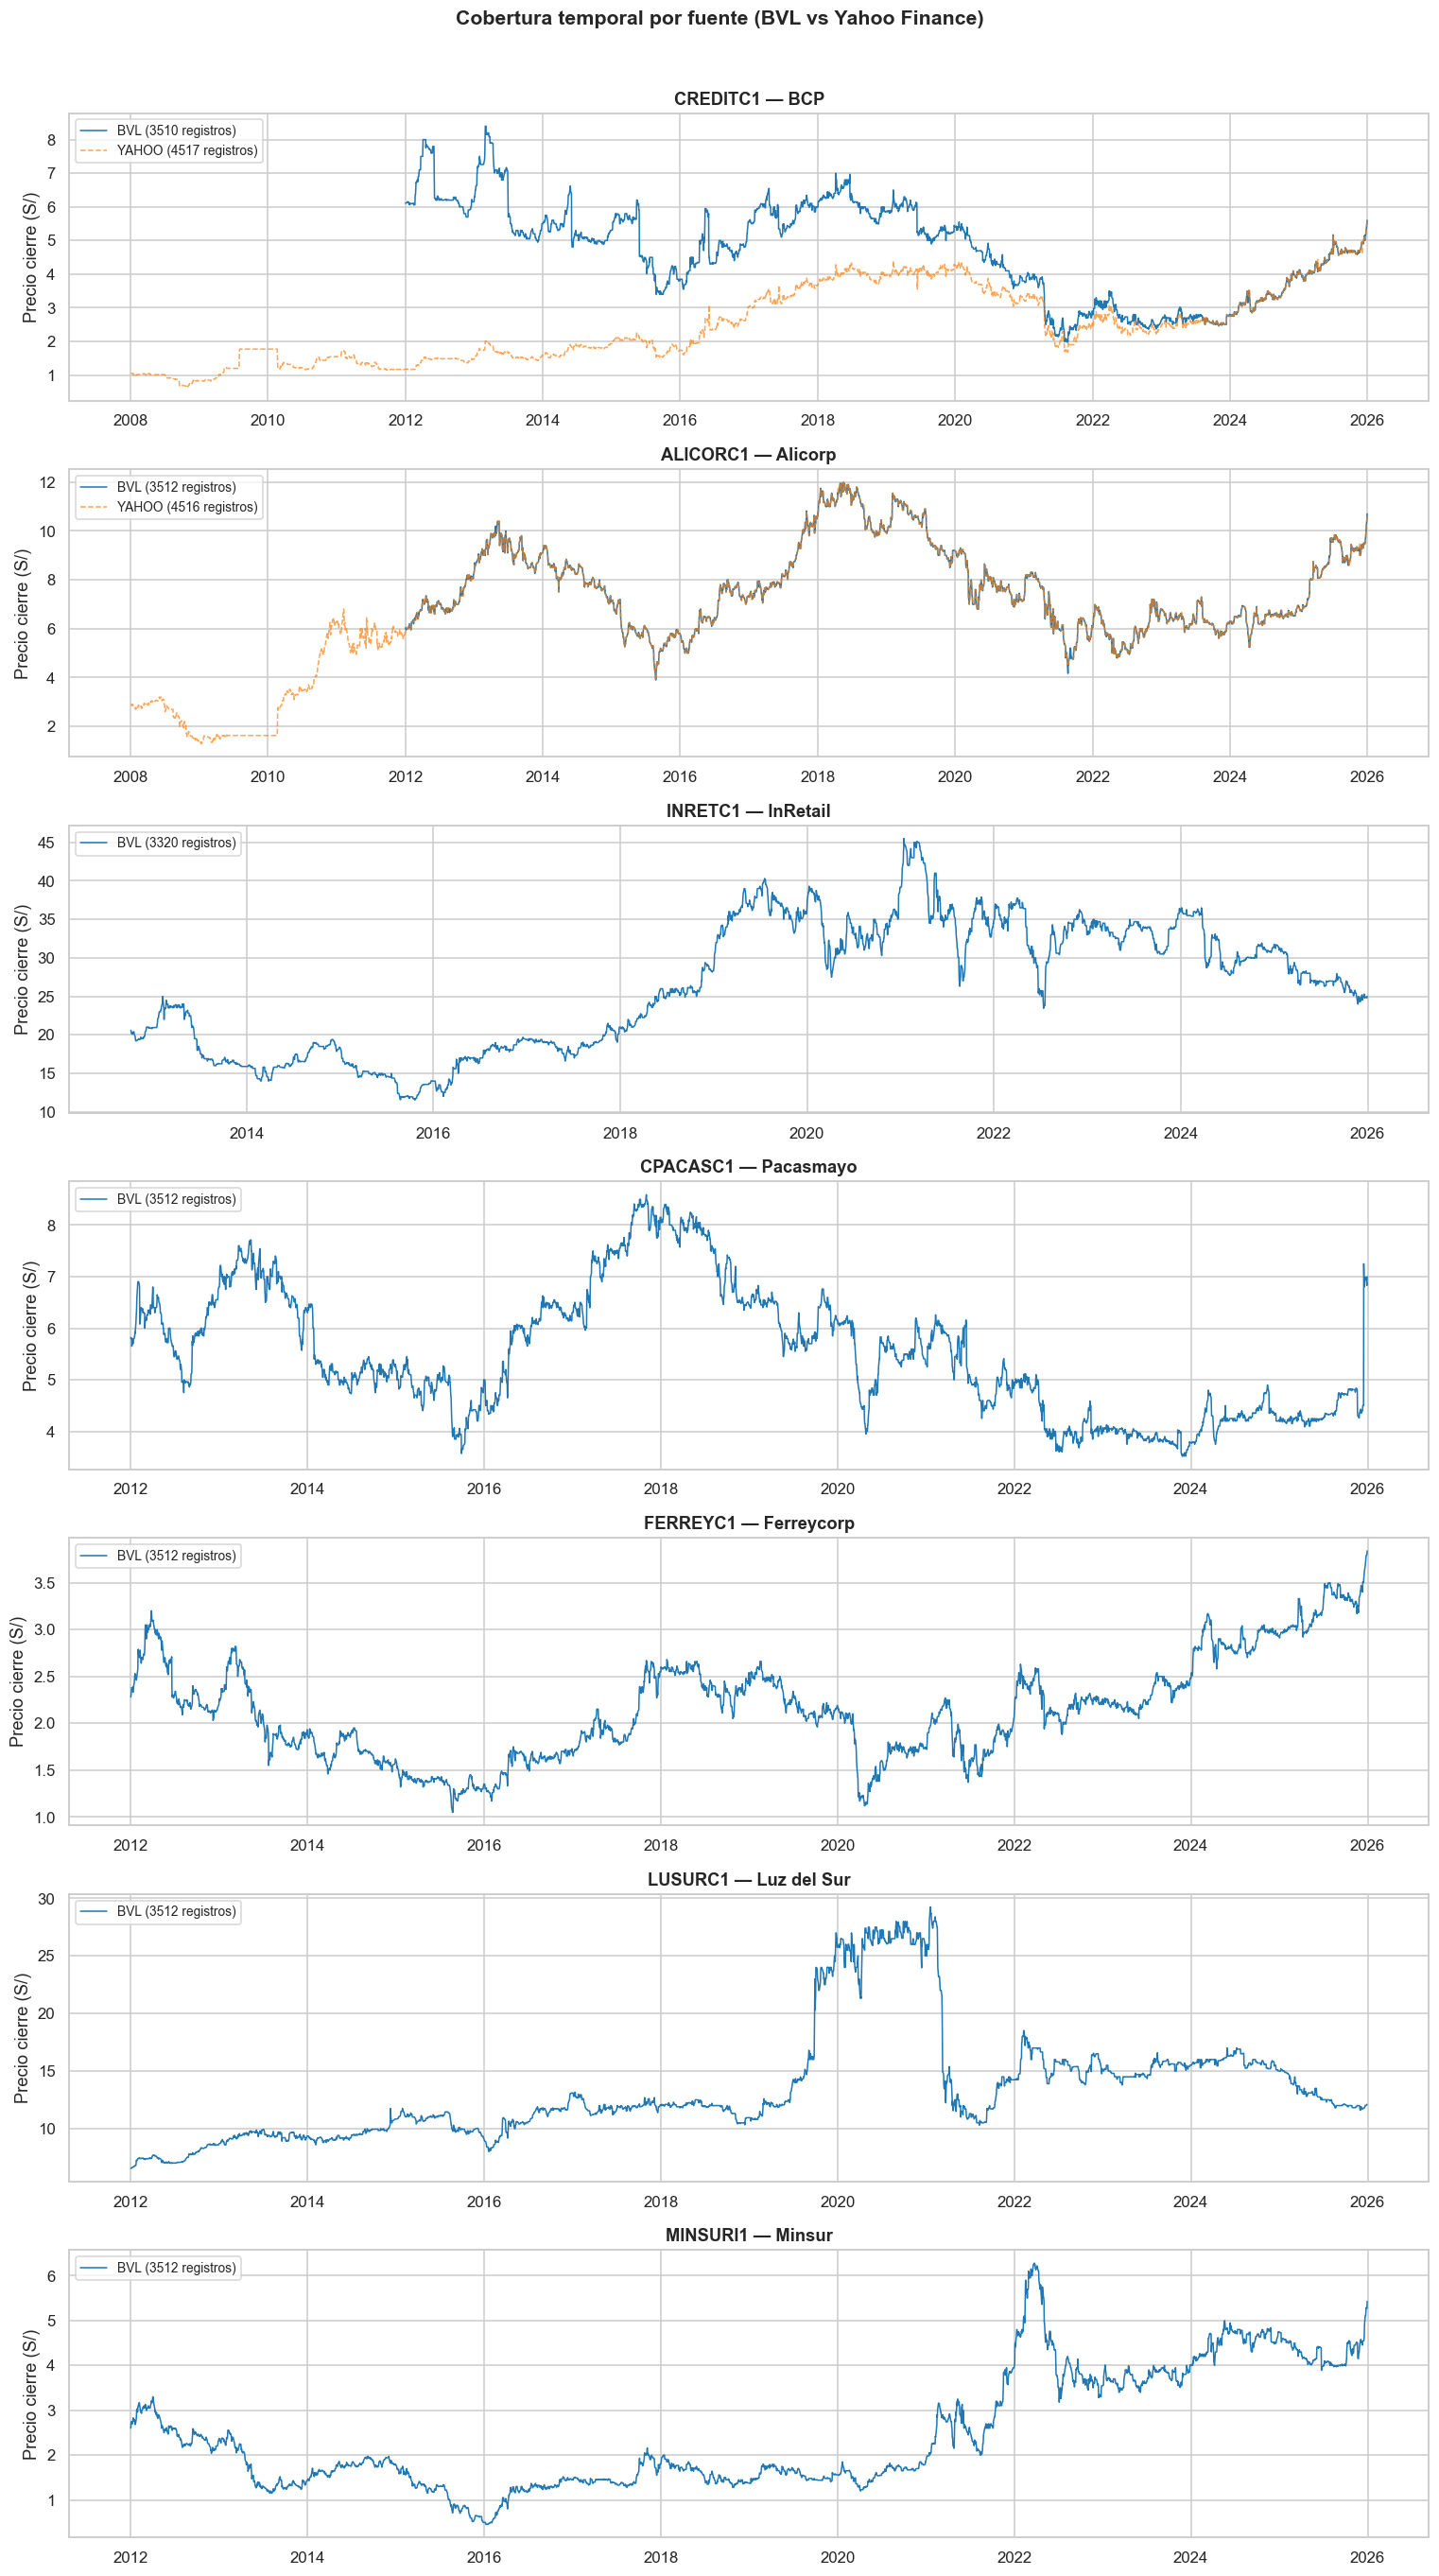

In [4]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3.5 * len(TICKERS)), sharex=False)
fig.suptitle('Cobertura temporal por fuente (BVL vs Yahoo Finance)', fontsize=14, fontweight='bold', y=1.01)

for ax, ticker, color in zip(axes, TICKERS, COLORES):
    srcs = raw.get(ticker, {})
    plotted = False
    for src, df_src in srcs.items():
        df_src = df_src.copy()
        df_src['date'] = pd.to_datetime(df_src['date'])
        df_src = df_src.sort_values('date')
        label = f'{src.upper()} ({len(df_src)} registros)'
        ls = '-' if src == 'bvl' else '--'
        alpha = 1.0 if src == 'bvl' else 0.7
        ax.plot(df_src['date'], df_src['close'], linewidth=1, linestyle=ls, alpha=alpha, label=label)
        plotted = True
    if not plotted and ticker in interim:
        df_i = interim[ticker]
        ax.plot(df_i['date'], df_i['close'], linewidth=1, color=color, label='interim (fusionado)')
    ax.set_title(f'{ticker} — {NOMBRES[ticker]}', fontweight='bold')
    ax.set_ylabel('Precio cierre (S/)')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 4. Precios normalizados (base 100) — índice de retorno total

Se grafica `close_total_return` (ajustado por splits/acciones liberadas y con
dividendos reinvertidos), no el cierre crudo: el cierre crudo de BCP cae casi todos
los años por sus acciones liberadas y daría una comparación engañosa. Base 100 en
la **primera fecha común a los siete** (2012-10-05, salida a bolsa de InRetail).

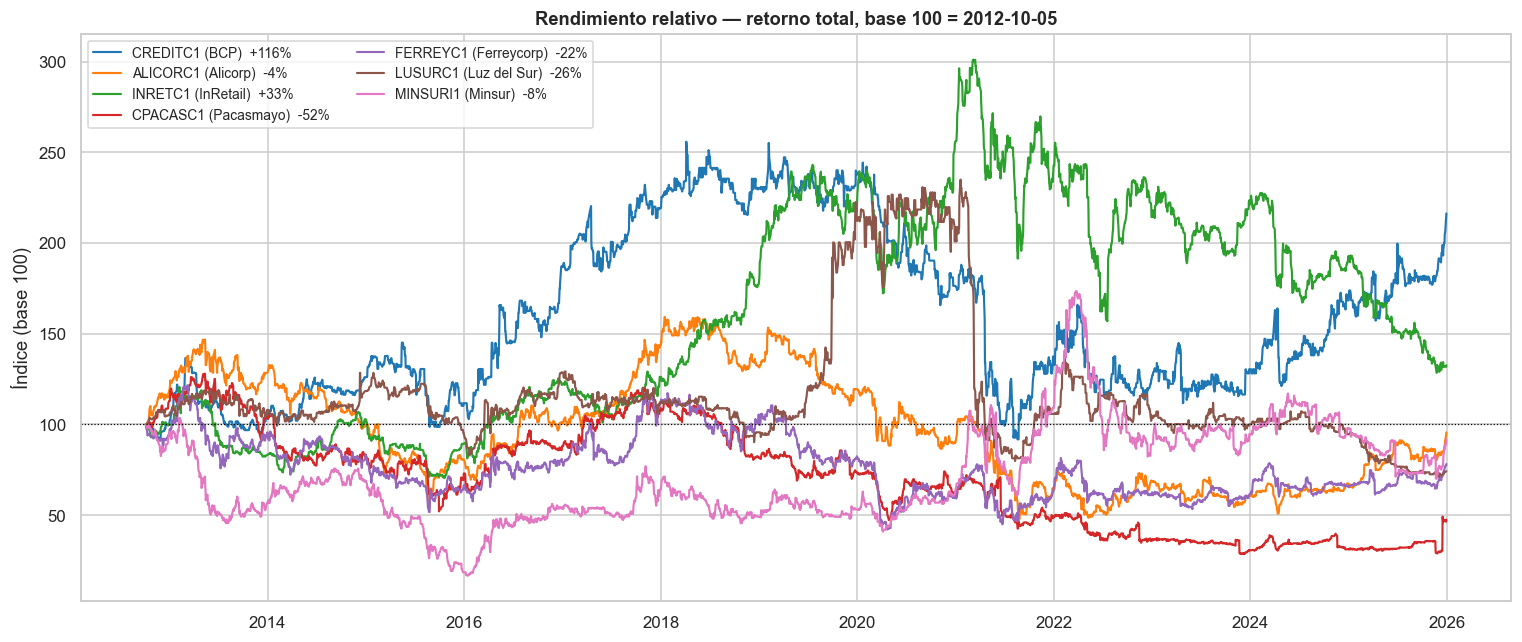

In [5]:
BASE_FECHA = max(df['date'].min() for df in interim.values())

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    df = interim.get(ticker)
    if df is None:
        continue
    s = df.set_index('date')['close_total_return']
    s = s[s.index >= BASE_FECHA]
    idx = s / s.iloc[0] * 100
    ax.plot(idx.index, idx.values, label=f'{ticker} ({NOMBRES[ticker]})  {idx.iloc[-1] - 100:+.0f}%',
            color=COLOR_MAP[ticker], linewidth=1.4)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title(f'Rendimiento relativo — retorno total, base 100 = {BASE_FECHA:%Y-%m-%d}', fontweight='bold')
ax.set_ylabel('Índice (base 100)')
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 5. Indicadores técnicos — CREDITC1 (BCP)

Todos los indicadores se calculan sobre `close_total_return`, así que el precio del
panel superior es esa misma serie (con el cierre crudo las medias móviles no
coincidirían con el precio en los años de acciones liberadas). El volumen proviene
del enriquecimiento de Yahoo (no autoritativo; la BVL no lo publica en su endpoint
diario). Para otro activo: `plot_tecnico('ALICORC1', interim['ALICORC1'])`.

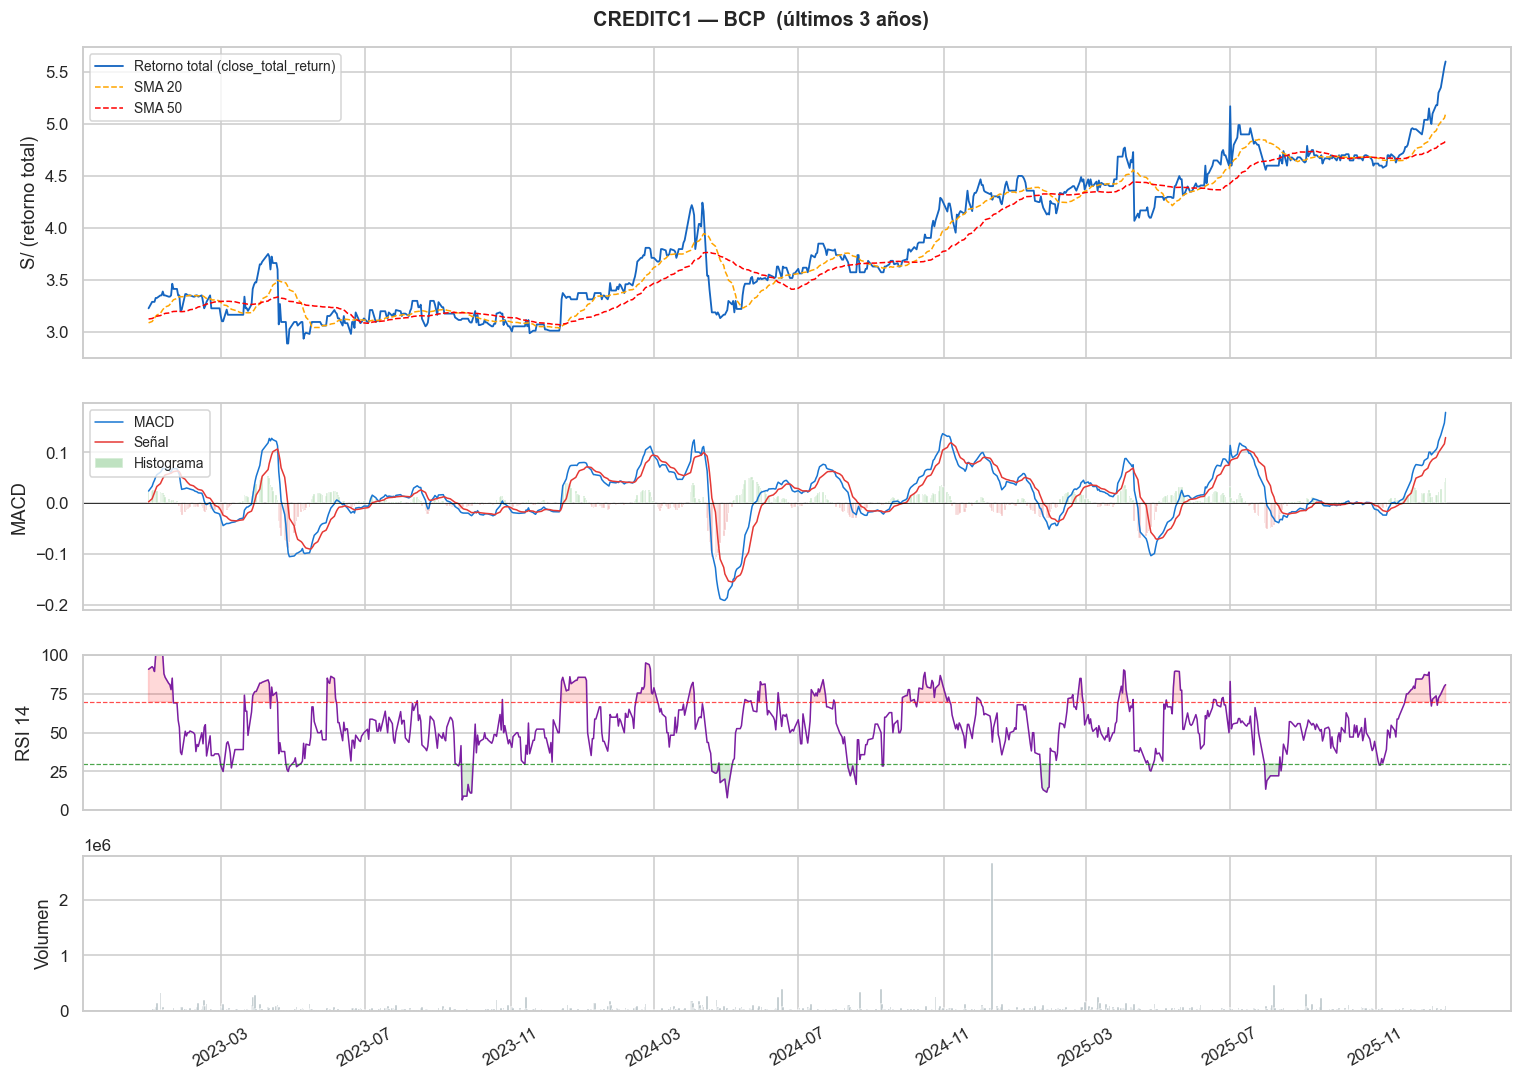

In [6]:
def plot_tecnico(ticker, df, ventana_años=3):
    """Panel de 4 subplots: Precio+SMA, MACD, RSI, Volumen."""
    fecha_fin = df['date'].max()
    fecha_ini = fecha_fin - pd.DateOffset(years=ventana_años)
    df = df[df['date'] >= fecha_ini].copy()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True,
                             gridspec_kw={'height_ratios': [3, 2, 1.5, 1.5]})
    fig.suptitle(f'{ticker} — {NOMBRES[ticker]}  (últimos {ventana_años} años)',
                 fontsize=13, fontweight='bold')

    # --- Precio + SMA ---
    ax = axes[0]
    ax.plot(df['date'], df['close_total_return'], color='#1565C0', linewidth=1.2,
            label='Retorno total (close_total_return)')
    if 'sma_20' in df: ax.plot(df['date'], df['sma_20'], '--', linewidth=1, color='orange', label='SMA 20')
    if 'sma_50' in df: ax.plot(df['date'], df['sma_50'], '--', linewidth=1, color='red',    label='SMA 50')
    ax.set_ylabel('S/ (retorno total)')
    ax.legend(loc='upper left', fontsize=9)

    # --- MACD ---
    ax = axes[1]
    if 'macd' in df and 'macd_signal' in df:
        ax.plot(df['date'], df['macd'],        color='#1976D2', linewidth=1, label='MACD')
        ax.plot(df['date'], df['macd_signal'], color='#E53935', linewidth=1, label='Señal')
        hist = df['macd'] - df['macd_signal']
        ax.bar(df['date'], hist, color=hist.apply(lambda x: '#81C784' if x >= 0 else '#E57373'),
               width=1.5, alpha=0.5, label='Histograma')
        ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('MACD')
    ax.legend(loc='upper left', fontsize=9)

    # --- RSI ---
    ax = axes[2]
    if 'rsi_14' in df:
        ax.plot(df['date'], df['rsi_14'], color='#7B1FA2', linewidth=1)
        ax.axhline(70, color='red',   linewidth=0.8, linestyle='--', alpha=0.7)
        ax.axhline(30, color='green', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.fill_between(df['date'], df['rsi_14'], 70,
                        where=(df['rsi_14'] > 70), alpha=0.15, color='red')
        ax.fill_between(df['date'], df['rsi_14'], 30,
                        where=(df['rsi_14'] < 30), alpha=0.15, color='green')
        ax.set_ylim(0, 100)
    ax.set_ylabel('RSI 14')

    # --- Volumen ---
    ax = axes[3]
    ax.bar(df['date'], df['volume'], color='#546E7A', width=1.5, alpha=0.7)
    ax.set_ylabel('Volumen')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

plot_tecnico('CREDITC1', interim['CREDITC1'])

## 6. Distribución de retornos diarios

`ret_1d` se calcula sobre `close_total_return` (ver sección 9) — libre de los
saltos de splits/dividendos que sí aparecen en el precio crudo.

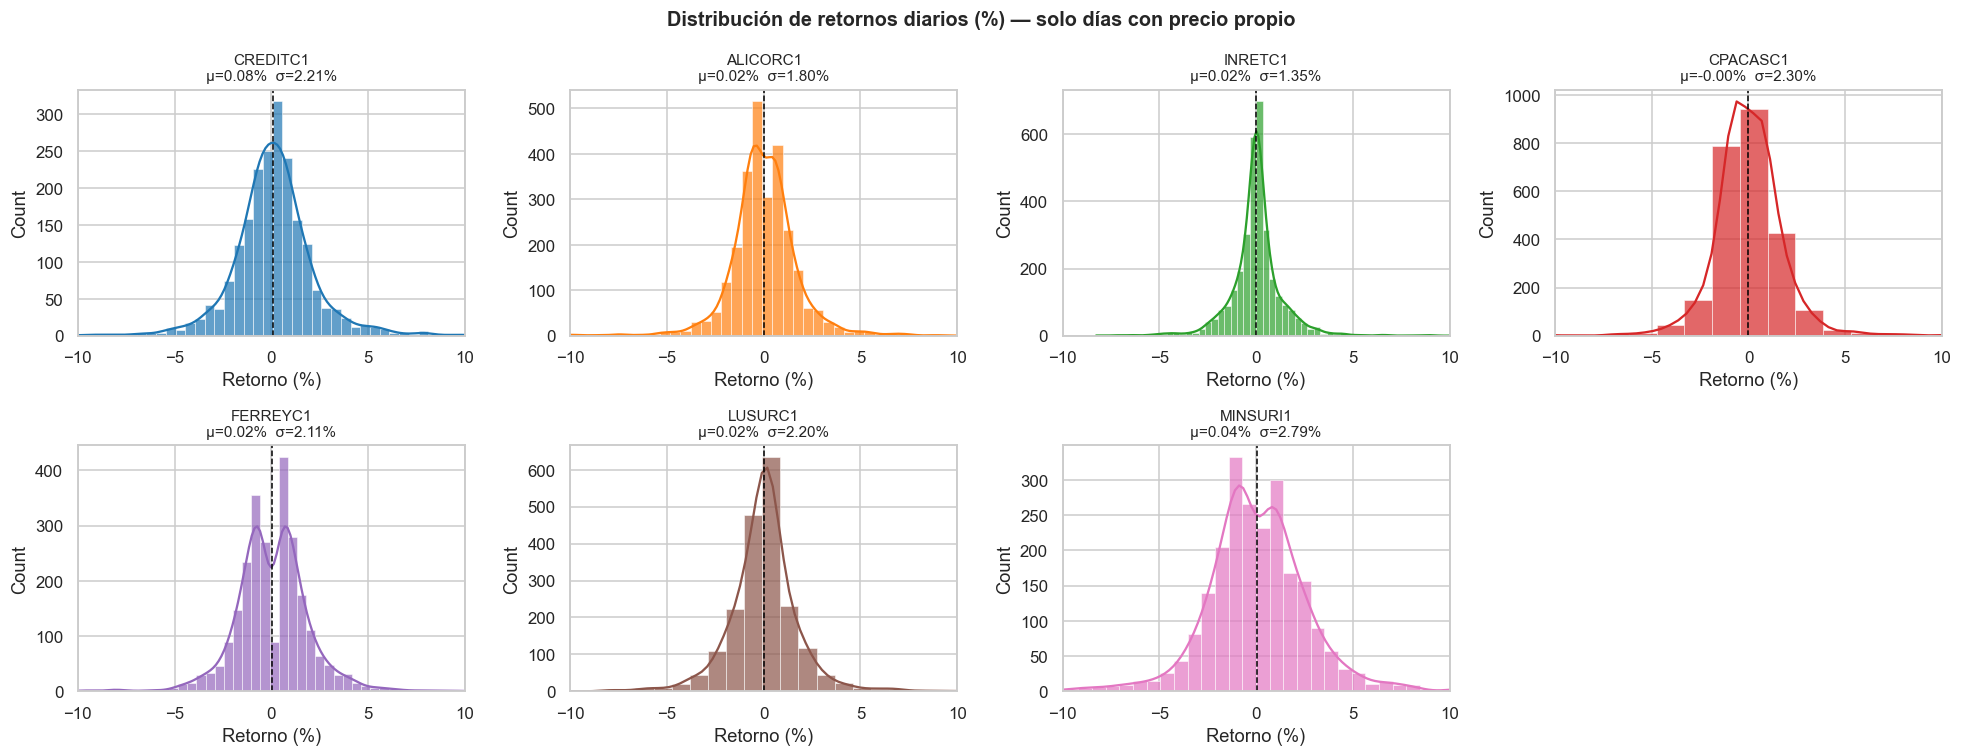

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
fig.suptitle('Distribución de retornos diarios (%) — solo días con precio propio', fontsize=13, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    df = interim.get(ticker)
    if df is None:
        continue
    propio = df['close_raw'] != df['close_raw'].shift(1)   # excluye días de precio arrastrado
    ret = df.loc[propio, 'ret_1d'].dropna() * 100
    sns.histplot(ret, bins=60, kde=True, ax=ax, color=COLOR_MAP[ticker], alpha=0.7)
    ax.axvline(ret.mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{ticker}\nμ={ret.mean():.2f}%  σ={ret.std():.2f}%', fontsize=10)
    ax.set_xlabel('Retorno (%)')
    ax.set_xlim(-10, 10)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Volatilidad anualizada (rolling 20 días)

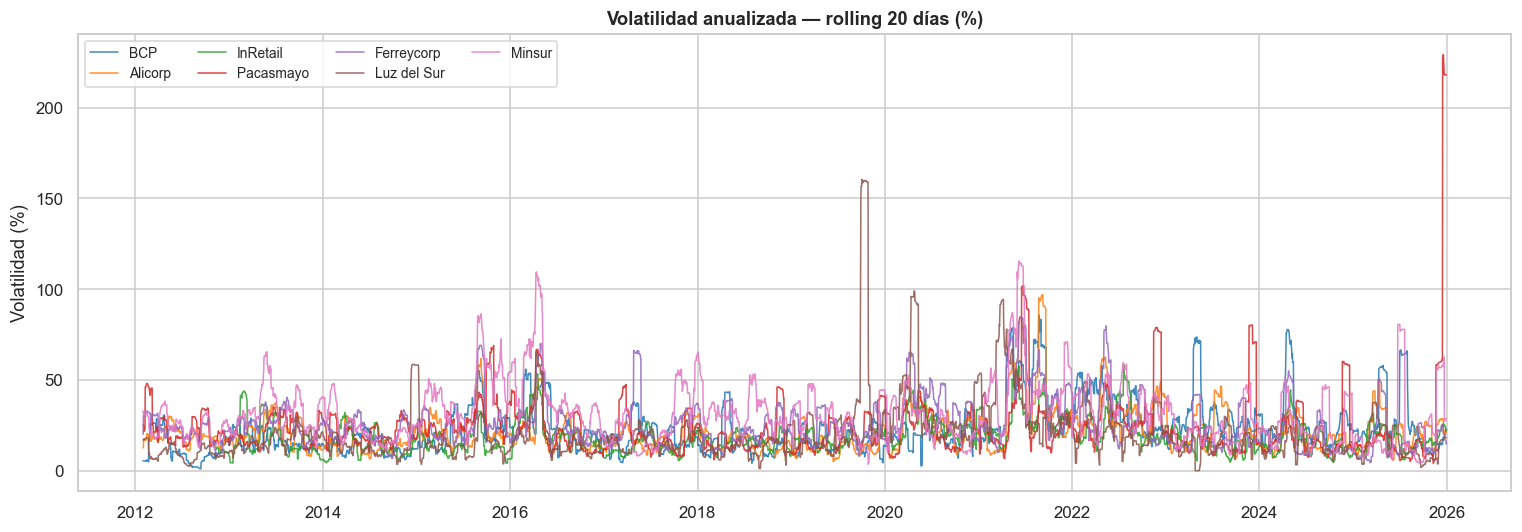

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TICKERS:
    df = interim.get(ticker)
    if df is None or 'volatility_20' not in df.columns:
        continue
    ax.plot(df['date'], df['volatility_20'] * 100, label=NOMBRES[ticker],
            color=COLOR_MAP[ticker], linewidth=1, alpha=0.85)
ax.set_title('Volatilidad anualizada — rolling 20 días (%)', fontweight='bold')
ax.set_ylabel('Volatilidad (%)')
ax.legend(ncol=4, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 8. Correlación de retornos entre empresas

Retornos diarios sobre `close_total_return`, desde 2012-10-05 (fecha común a los
siete). Se usan todas las fechas del calendario: los días de precio arrastrado
aportan retornos cero y ATENÚAN la correlación (la iliquidez de la BVL es parte de
lo que se describe). La tabla de abajo repite el cálculo solo con días en que
ambos activos tuvieron precio propio, para dimensionar ese efecto.

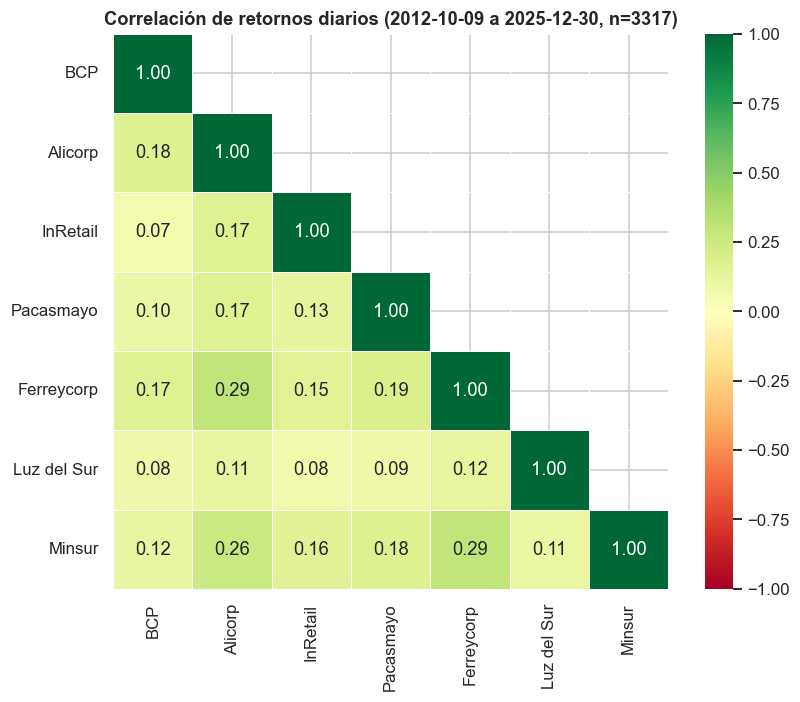

Correlación media por pares — todas las fechas: 0.152 | solo días con precio propio en ambos: 0.206

Estadísticas de retornos diarios:
             BCP    Alicorp   InRetail  Pacasmayo  Ferreycorp  Luz del Sur  \
count  3317.0000  3317.0000  3317.0000  3317.0000   3317.0000    3317.0000   
mean      0.0004     0.0001     0.0002    -0.0000      0.0001       0.0000   
std       0.0173     0.0159     0.0132     0.0197      0.0182       0.0169   
min      -0.1500    -0.1963    -0.0826    -0.2478     -0.1569      -0.1505   
25%      -0.0028    -0.0055    -0.0045    -0.0062     -0.0068      -0.0009   
50%       0.0000     0.0000     0.0000     0.0000      0.0000       0.0000   
75%       0.0038     0.0058     0.0046     0.0058      0.0072       0.0012   
max       0.1515     0.1207     0.1159     0.6111      0.1268       0.4110   

          Minsur  
count  3317.0000  
mean      0.0002  
std       0.0229  
min      -0.2259  
25%      -0.0071  
50%       0.0000  
75%       0.0070  
max       

In [9]:
retornos, propio = {}, {}
for ticker, df in interim.items():
    s = df.set_index('date')
    retornos[NOMBRES[ticker]] = s['ret_1d']
    propio[NOMBRES[ticker]] = s['close_raw'] != s['close_raw'].shift(1)

df_ret = pd.DataFrame(retornos).dropna()
df_prop = pd.DataFrame(propio).reindex(df_ret.index).fillna(False)
corr = df_ret.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            ax=ax, mask=mask, square=True, linewidths=0.5)
ax.set_title(f'Correlación de retornos diarios ({df_ret.index.min():%Y-%m-%d} a '
             f'{df_ret.index.max():%Y-%m-%d}, n={len(df_ret)})', fontweight='bold')
plt.tight_layout()
plt.show()

# Sensibilidad: solo pares de días con precio propio en ambos activos
cols = list(df_ret.columns)
corr_prop = pd.DataFrame(index=cols, columns=cols, dtype=float)
for a in cols:
    for b in cols:
        m = df_prop[a] & df_prop[b]
        corr_prop.loc[a, b] = df_ret.loc[m, a].corr(df_ret.loc[m, b])
iu = np.triu_indices(len(cols), k=1)
print(f"Correlación media por pares — todas las fechas: {corr.values[iu].mean():.3f} | "
      f"solo días con precio propio en ambos: {corr_prop.values[iu].mean():.3f}")
print("\nEstadísticas de retornos diarios:")
print(df_ret.describe().round(4))

## 9. Acciones corporativas: close_raw vs close_split_adj vs close_total_return

Capa de ajuste por acciones corporativas (`src/market/corporate_actions.py`).
Para cada activo se calculan tres series de precio:

- **close_raw** — precio efectivamente negociado (= `close`).
- **close_split_adj** — ajustado por splits / acciones liberadas (convencion
  CRSP, ajuste hacia atras). Base para un P/E consistente con el EPS.
- **close_total_return** — ajustado por splits y dividendos reinvertidos. Es
  la serie sobre la que se calculan los indicadores tecnicos (`ret_1d`,
  `sma_*`, `rsi_14`, etc.) — la que ve el agente DRL.

**Fuente (jul-2026):** splits y dividendos provienen ahora de la BVL nativa
(dataondemand `/v1/issuers/{companyCode}/value`), no de yfinance. Los 7 activos
quedan ajustados (dividendos en US$ convertidos a PEN con el tipo de cambio del BCRP).
Cada split se alinea a la fecha real de la caida de precio, porque la BVL los
fecha por *dateCut* (corte), que puede adelantarse unos dias a la ex-date
efectiva (sin alinear, CORAREC1 mostraba un salto ficticio de +40% en 2012-06-12).

CREDITC1 (BCP) distribuye acciones liberadas casi todos los anios, lo que
producia caidas artificiales de hasta -28% en `close_raw` de un dia para otro.
Esas caidas desaparecen en `close_split_adj`/`close_total_return`.


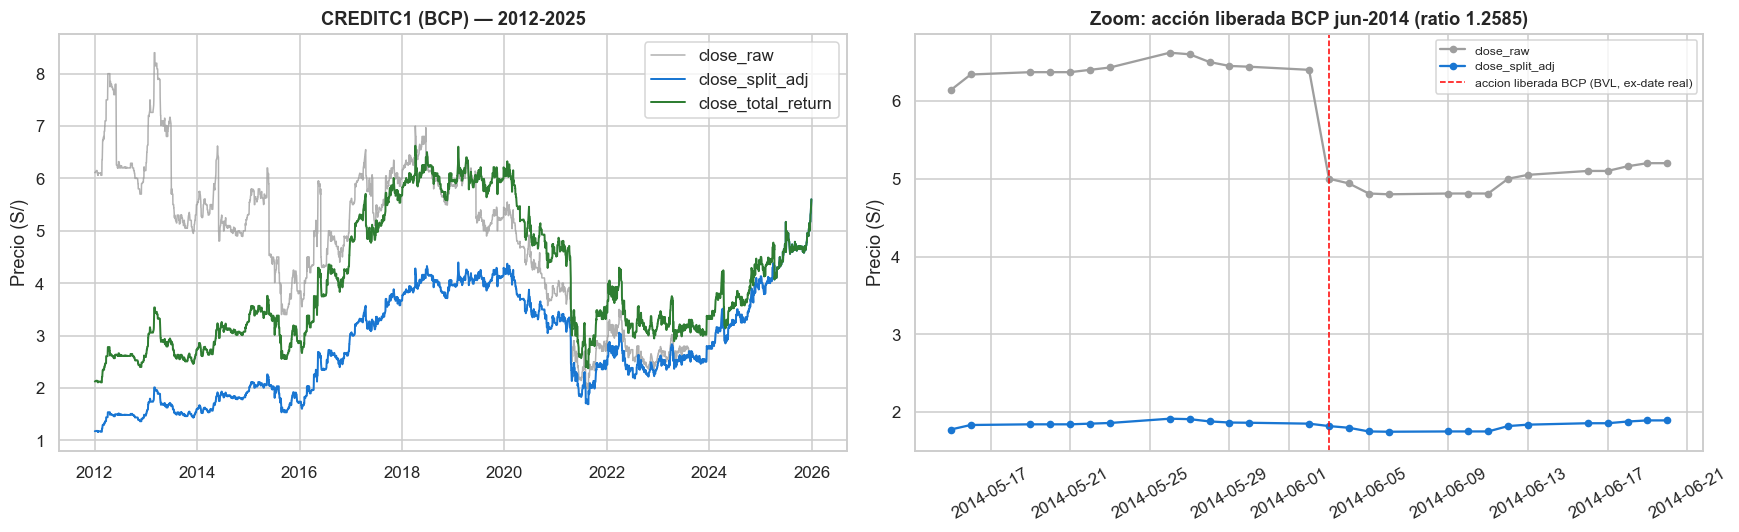

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df = interim['CREDITC1']

ax = axes[0]
ax.plot(df['date'], df['close_raw'], label='close_raw', linewidth=1, alpha=0.8, color='#9E9E9E')
ax.plot(df['date'], df['close_split_adj'], label='close_split_adj', linewidth=1.3, color='#1976D2')
ax.plot(df['date'], df['close_total_return'], label='close_total_return', linewidth=1.3, color='#2E7D32')
ax.set_title('CREDITC1 (BCP) — 2012-2025', fontweight='bold')
ax.set_ylabel('Precio (S/)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1]
win = df[(df['date'] >= '2014-05-15') & (df['date'] <= '2014-06-20')]
ax.plot(win['date'], win['close_raw'], 'o-', label='close_raw', markersize=4, color='#9E9E9E')
ax.plot(win['date'], win['close_split_adj'], 'o-', label='close_split_adj', markersize=4, color='#1976D2')
ax.axvline(pd.Timestamp('2014-06-03'), color='red', linestyle='--', linewidth=1,
          label='accion liberada BCP (BVL, ex-date real)')
ax.set_title('Zoom: acción liberada BCP jun-2014 (ratio 1.2585)', fontweight='bold')
ax.set_ylabel('Precio (S/)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

In [11]:
filas = []
for ticker, df in interim.items():
    for col in ['close_raw', 'close_split_adj', 'close_total_return']:
        ret = df.sort_values('date')[col].pct_change()
        filas.append({
            'Ticker': ticker, 'Serie': col,
            'max |ret|': ret.abs().max(),
            'n > 40%': int((ret.abs() > 0.40).sum()),
            'n > 100%': int((ret.abs() > 1.00).sum()),
        })
tabla = pd.DataFrame(filas)
orden_series = ['close_raw', 'close_split_adj', 'close_total_return']

print('Saltos diarios > 40% por serie (antes/despues del ajuste):')
display(tabla.pivot(index='Ticker', columns='Serie', values='n > 40%')[orden_series])

print()
print('Saltos diarios > 100% por serie:')
display(tabla.pivot(index='Ticker', columns='Serie', values='n > 100%')[orden_series])

print()
print('Retorno diario maximo absoluto por serie:')
display(tabla.pivot(index='Ticker', columns='Serie', values='max |ret|')[orden_series].round(3))

Saltos diarios > 40% por serie (antes/despues del ajuste):


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0,0,0
CPACASC1,1,1,1
CREDITC1,0,0,0
FERREYC1,0,0,0
INRETC1,0,0,0
LUSURC1,1,1,1
MINSURI1,0,0,0



Saltos diarios > 100% por serie:


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0,0,0
CPACASC1,0,0,0
CREDITC1,0,0,0
FERREYC1,0,0,0
INRETC1,0,0,0
LUSURC1,0,0,0
MINSURI1,0,0,0



Retorno diario maximo absoluto por serie:


Serie,close_raw,close_split_adj,close_total_return
Ticker,,,
ALICORC1,0.151,0.151,0.196
CPACASC1,0.611,0.611,0.611
CREDITC1,0.232,0.152,0.152
FERREYC1,0.162,0.153,0.157
INRETC1,0.116,0.116,0.116
LUSURC1,0.411,0.411,0.411
MINSURI1,0.198,0.198,0.226


In [12]:
flags = pd.DataFrame({
    ticker: df[['is_split_adjusted', 'is_div_adjusted']].iloc[0]
    for ticker, df in interim.items()
}).T
flags.index.name = 'Ticker'
print('Flags de ajuste por acciones corporativas:')
display(flags)

Flags de ajuste por acciones corporativas:


,is_split_adjusted,is_div_adjusted
Ticker,,
CREDITC1,True,True
ALICORC1,False,True
INRETC1,False,True
CPACASC1,False,True
FERREYC1,True,True
LUSURC1,False,True
MINSURI1,True,True


## 10. Vista de muestra — datos raw BVL

In [13]:
for ticker in TICKERS:
    for src in ('bvl', 'yahoo'):
        p = DATA_RAW / f'market_{ticker}_{src}.parquet'
        if p.exists():
            df = pd.read_parquet(p)
            print(f'\n=== {ticker} [{src.upper()}] — {len(df)} filas ===')
            display(df.tail(5))


=== CREDITC1 [BVL] — 3510 filas ===


,ticker,date,open,high,low,close,volume,source
3505,CREDITC1,2025-12-23,5.18,5.18,5.18,5.18,NaN,bvl
3506,CREDITC1,2025-12-24,5.30,5.30,5.30,5.30,NaN,bvl
3507,CREDITC1,2025-12-26,5.35,5.35,5.35,5.35,NaN,bvl
3508,CREDITC1,2025-12-29,5.55,5.55,5.55,5.55,NaN,bvl
3509,CREDITC1,2025-12-30,5.60,5.60,5.60,5.60,NaN,bvl



=== CREDITC1 [YAHOO] — 4517 filas ===


,ticker,date,open,high,low,close,volume,source
4512,CREDITC1,2025-12-23,5.20,5.20,5.18,5.18,46143,yahoo
4513,CREDITC1,2025-12-24,5.30,5.30,5.30,5.30,11317,yahoo
4514,CREDITC1,2025-12-26,5.39,5.39,5.35,5.35,23838,yahoo
4515,CREDITC1,2025-12-29,5.50,5.55,5.50,5.55,33333,yahoo
4516,CREDITC1,2025-12-30,5.60,5.60,5.60,5.60,78334,yahoo



=== ALICORC1 [BVL] — 3512 filas ===


...

,ticker,date,open,high,low,close,volume,source
3507,FERREYC1,2025-12-23,3.71,3.71,3.71,3.71,NaN,bvl
3508,FERREYC1,2025-12-24,3.73,3.73,3.73,3.73,NaN,bvl
3509,FERREYC1,2025-12-26,3.79,3.79,3.79,3.79,NaN,bvl
3510,FERREYC1,2025-12-29,3.80,3.80,3.80,3.80,NaN,bvl
3511,FERREYC1,2025-12-30,3.84,3.84,3.84,3.84,NaN,bvl



=== LUSURC1 [BVL] — 3512 filas ===


,ticker,date,open,high,low,close,volume,source
3507,LUSURC1,2025-12-23,12.01,12.01,12.01,12.01,NaN,bvl
3508,LUSURC1,2025-12-24,12.01,12.01,12.01,12.01,NaN,bvl
3509,LUSURC1,2025-12-26,12.02,12.02,12.02,12.02,NaN,bvl
3510,LUSURC1,2025-12-29,12.10,12.10,12.10,12.10,NaN,bvl
3511,LUSURC1,2025-12-30,12.10,12.10,12.10,12.10,NaN,bvl



=== MINSURI1 [BVL] — 3512 filas ===


,ticker,date,open,high,low,close,volume,source
3507,MINSURI1,2025-12-23,5.10,5.10,5.10,5.10,NaN,bvl
3508,MINSURI1,2025-12-24,5.12,5.12,5.12,5.12,NaN,bvl
3509,MINSURI1,2025-12-26,5.29,5.29,5.29,5.29,NaN,bvl
3510,MINSURI1,2025-12-29,5.27,5.27,5.27,5.27,NaN,bvl
3511,MINSURI1,2025-12-30,5.43,5.43,5.43,5.43,NaN,bvl


## 11. Vista de muestra — datos interim (con acciones corporativas + indicadores tecnicos)

In [14]:
for ticker, df in interim.items():
    print(f'=== {ticker} ({NOMBRES[ticker]}) -- {len(df)} filas ===')
    cols_show = [c for c in ['date','open','high','low','close','volume','source',
                              'close_raw','close_split_adj','close_total_return',
                              'is_split_adjusted','is_div_adjusted',
                              'ret_1d','ret_1d_raw','sma_20','sma_50','rsi_14','macd','volatility_20']
                 if c in df.columns]
    display(df[cols_show].tail(8).round(4))

=== CREDITC1 (BCP) -- 3510 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3502,2025-12-18,5.05,5.05,5.05,5.00,0.0,bvl,5.00,5.00,5.00,True,True,-0.0099,-0.0099,4.8880,4.7516,67.1875,0.0951,0.1764
3503,2025-12-19,5.00,5.10,5.00,5.10,80334.0,bvl,5.10,5.10,5.10,True,True,0.0200,0.0200,4.9100,4.7594,71.6216,0.0979,0.1853
3504,2025-12-22,5.10,5.18,5.10,5.18,13980.0,bvl,5.18,5.18,5.18,True,True,0.0157,0.0157,4.9350,4.7688,73.7500,0.1054,0.1894
3505,2025-12-23,5.20,5.20,5.18,5.18,46143.0,bvl,5.18,5.18,5.18,True,True,0.0000,0.0000,4.9590,4.7794,67.6923,0.1101,0.1903
3506,2025-12-24,5.30,5.30,5.30,5.30,11317.0,bvl,5.30,5.30,5.30,True,True,0.0232,0.0232,4.9880,4.7924,72.3684,0.1221,0.2009
3507,2025-12-26,5.39,5.39,5.35,5.35,23838.0,bvl,5.35,5.35,5.35,True,True,0.0094,0.0094,5.0185,4.8054,75.0000,0.1340,0.2012
3508,2025-12-29,5.50,5.55,5.50,5.55,33333.0,bvl,5.55,5.55,5.55,True,True,0.0374,0.0374,5.0570,4.8224,80.0000,0.1579,0.2298
3509,2025-12-30,5.60,5.60,5.60,5.60,78334.0,bvl,5.60,5.60,5.60,True,True,0.0090,0.0090,5.0980,4.8404,80.9524,0.1787,0.2281


=== ALICORC1 (Alicorp) -- 3512 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3504,2025-12-18,9.47,9.47,9.47,9.51,0.0,bvl,9.51,9.51,9.51,False,True,0.0042,0.0042,9.3045,9.4967,67.8261,0.0122,0.2863
3505,2025-12-19,9.75,9.75,9.50,9.50,18126.0,bvl,9.50,9.50,9.50,False,True,-0.0011,-0.0011,9.3220,9.4915,66.6667,0.0172,0.2111
3506,2025-12-22,9.65,9.75,9.65,9.75,33725.0,bvl,9.75,9.75,9.75,False,True,0.0263,0.0263,9.3445,9.4913,68.5950,0.0410,0.2228
3507,2025-12-23,9.80,9.85,9.80,9.85,13896.0,bvl,9.85,9.85,9.85,False,True,0.0103,0.0103,9.3870,9.4960,67.2414,0.0671,0.1823
3508,2025-12-24,10.00,10.00,9.95,9.95,7216.0,bvl,9.95,9.95,9.95,False,True,0.0102,0.0102,9.4345,9.5040,80.0000,0.0947,0.1825
3509,2025-12-26,10.00,10.25,10.00,10.25,21255.0,bvl,10.25,10.25,10.25,False,True,0.0302,0.0302,9.4920,9.5169,84.2857,0.1392,0.2023
3510,2025-12-29,10.50,10.50,10.50,10.50,18801.0,bvl,10.50,10.50,10.50,False,True,0.0244,0.0244,9.5620,9.5348,85.2349,0.1925,0.2109
3511,2025-12-30,10.50,10.70,10.50,10.70,23994.0,bvl,10.70,10.70,10.70,False,True,0.0190,0.0190,9.6410,9.5561,95.4545,0.2480,0.2140


=== INRETC1 (InRetail) -- 3320 filas ===


...

,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3504,2025-12-18,3.60,3.60,3.60,3.60,NaN,bvl,3.60,3.60,3.60,True,True,0.0084,0.0084,3.3880,3.3378,84.3137,0.0693,0.2136
3505,2025-12-19,3.63,3.63,3.63,3.63,NaN,bvl,3.63,3.63,3.63,True,True,0.0083,0.0083,3.4070,3.3438,82.2222,0.0765,0.2020
3506,2025-12-22,3.68,3.68,3.68,3.68,NaN,bvl,3.68,3.68,3.68,True,True,0.0138,0.0138,3.4290,3.3512,83.6735,0.0852,0.2012
3507,2025-12-23,3.71,3.71,3.71,3.71,NaN,bvl,3.71,3.71,3.71,True,True,0.0082,0.0082,3.4525,3.3590,84.0000,0.0934,0.1998
3508,2025-12-24,3.73,3.73,3.73,3.73,NaN,bvl,3.73,3.73,3.73,True,True,0.0054,0.0054,3.4800,3.3658,83.3333,0.1004,0.1761
3509,2025-12-26,3.79,3.79,3.79,3.79,NaN,bvl,3.79,3.79,3.79,True,True,0.0161,0.0161,3.5065,3.3742,85.1852,0.1095,0.1672
3510,2025-12-29,3.80,3.80,3.80,3.80,NaN,bvl,3.80,3.80,3.80,True,True,0.0026,0.0026,3.5340,3.3828,84.6154,0.1162,0.1635
3511,2025-12-30,3.84,3.84,3.84,3.84,NaN,bvl,3.84,3.84,3.84,True,True,0.0105,0.0105,3.5590,3.3926,84.9057,0.1233,0.1464


=== LUSURC1 (Luz del Sur) -- 3512 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3504,2025-12-18,11.80,11.80,11.80,11.80,NaN,bvl,11.80,11.80,11.80,False,True,0.0000,0.0000,11.8450,11.8888,40.0000,-0.0385,0.1678
3505,2025-12-19,11.80,11.80,11.80,11.80,NaN,bvl,11.80,11.80,11.80,False,True,0.0000,0.0000,11.8350,11.8846,40.0000,-0.0352,0.1678
3506,2025-12-22,12.01,12.01,12.01,12.01,NaN,bvl,12.01,12.01,12.01,False,True,0.0178,0.0178,11.8355,11.8846,50.4132,-0.0154,0.1803
3507,2025-12-23,12.01,12.01,12.01,12.01,NaN,bvl,12.01,12.01,12.01,False,True,0.0000,0.0000,11.8360,11.8868,75.3086,0.0002,0.1803
3508,2025-12-24,12.01,12.01,12.01,12.01,NaN,bvl,12.01,12.01,12.01,False,True,0.0000,0.0000,11.8365,11.8890,75.3086,0.0125,0.1803
3509,2025-12-26,12.02,12.02,12.02,12.02,NaN,bvl,12.02,12.02,12.02,False,True,0.0008,0.0008,11.8375,11.8894,75.6098,0.0228,0.1804
3510,2025-12-29,12.10,12.10,12.10,12.10,NaN,bvl,12.10,12.10,12.10,False,True,0.0067,0.0067,11.8425,11.8914,66.6667,0.0369,0.1818
3511,2025-12-30,12.10,12.10,12.10,12.10,NaN,bvl,12.10,12.10,12.10,False,True,0.0000,0.0000,11.8475,11.8934,66.6667,0.0476,0.1818


=== MINSURI1 (Minsur) -- 3512 filas ===


,date,open,high,low,close,volume,source,close_raw,close_split_adj,close_total_return,is_split_adjusted,is_div_adjusted,ret_1d,ret_1d_raw,sma_20,sma_50,rsi_14,macd,volatility_20
3504,2025-12-18,4.67,4.67,4.67,4.67,NaN,bvl,4.67,4.67,4.67,True,True,0.0219,0.0219,4.4942,4.6735,76.8116,-0.0142,0.5822
3505,2025-12-19,4.90,4.90,4.90,4.90,NaN,bvl,4.90,4.90,4.90,True,True,0.0493,0.0493,4.4951,4.6772,83.5165,0.0145,0.6095
3506,2025-12-22,5.10,5.10,5.10,5.10,NaN,bvl,5.10,5.10,5.10,True,True,0.0408,0.0408,4.5060,4.6815,85.0000,0.0527,0.6257
3507,2025-12-23,5.10,5.10,5.10,5.10,NaN,bvl,5.10,5.10,5.10,True,True,0.0000,0.0000,4.5530,4.6861,82.9545,0.0821,0.2745
3508,2025-12-24,5.12,5.12,5.12,5.12,NaN,bvl,5.12,5.12,5.12,True,True,0.0039,0.0039,4.6015,4.6902,85.2273,0.1058,0.2715
3509,2025-12-26,5.29,5.29,5.29,5.29,NaN,bvl,5.29,5.29,5.29,True,True,0.0332,0.0332,4.6535,4.6986,86.8687,0.1367,0.2793
3510,2025-12-29,5.27,5.27,5.27,5.27,NaN,bvl,5.27,5.27,5.27,True,True,-0.0038,-0.0038,4.7020,4.7064,84.8485,0.1577,0.2842
3511,2025-12-30,5.43,5.43,5.43,5.43,NaN,bvl,5.43,5.43,5.43,True,True,0.0304,0.0304,4.7590,4.7162,90.0901,0.1852,0.2885
